<a href="https://colab.research.google.com/github/bharath-hue/TASK_TNS_AIML/blob/main/Recurrent_Neural_Network_(RNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.6926 - loss: 0.5855 - val_accuracy: 0.7362 - val_loss: 0.5473
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 55ms/step - accuracy: 0.8411 - loss: 0.3776 - val_accuracy: 0.8236 - val_loss: 0.4183
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.8684 - loss: 0.3382 - val_accuracy: 0.5268 - val_loss: 0.7063
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.8647 - loss: 0.3214 - val_accuracy: 0.8334 - val_loss: 0.4306
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.9459 - loss: 0.1512 - val_accuracy: 0.8280 - val_loss: 0.4599
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8303 - loss: 0.4569
Test Accuracy: 0.8302800059318542


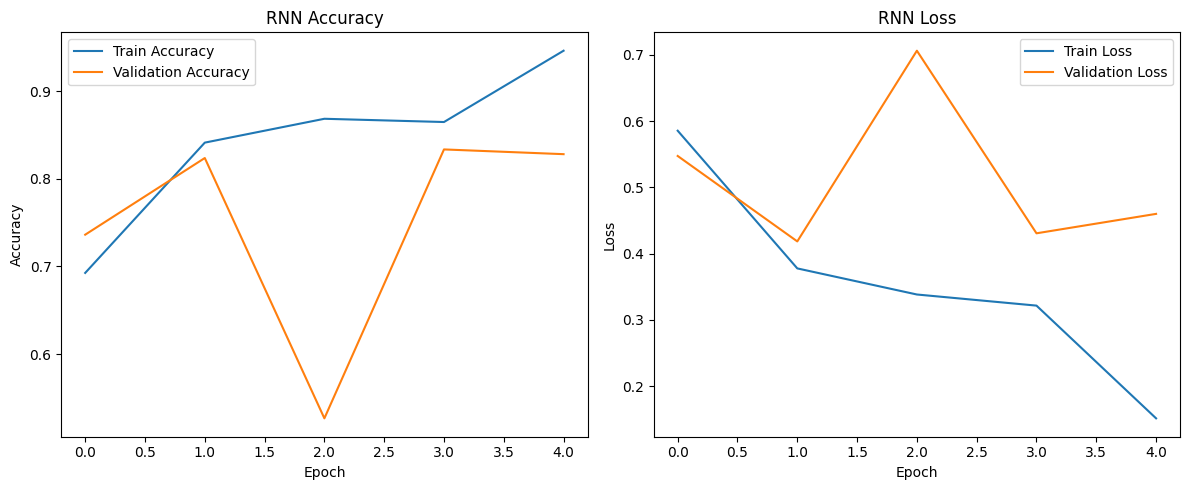

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
Review 1: Negative (Probability=0.2047)
Review 2: Positive (Probability=0.9921)
Review 3: Negative (Probability=0.4539)
Review 4: Positive (Probability=0.9413)
Review 5: Positive (Probability=0.9920)
Review 6: Positive (Probability=0.6585)
Review 7: Positive (Probability=0.9844)
Review 8: Negative (Probability=0.1262)
Review 9: Positive (Probability=0.9761)
Review 10: Positive (Probability=0.9268)


In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Parameters
vocab_size = 10000
max_length = 200

# Load IMDB Dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

# Pad sequences
X_train = pad_sequences(
    X_train,
    maxlen=max_length
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length
)

# Build RNN Model
model = Sequential([
    Embedding(vocab_size, 32,
              input_length=max_length),

    SimpleRNN(32),

    Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# Evaluate
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

# -----------------------------
# Accuracy Visualization
# -----------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],
         label='Train Accuracy')
plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')
plt.title('RNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# -----------------------------
# Loss Visualization
# -----------------------------
plt.subplot(1,2,2)
plt.plot(history.history['loss'],
         label='Train Loss')
plt.plot(history.history['val_loss'],
         label='Validation Loss')
plt.title('RNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# Predictions
# -----------------------------
predictions = model.predict(X_test[:10])

for i in range(10):
    sentiment = "Positive" if predictions[i] > 0.5 else "Negative"
    print(
        f"Review {i+1}: "
        f"{sentiment} "
        f"(Probability={predictions[i][0]:.4f})"
    )